In [72]:
from rasterio.features import geometry_mask
import xarray as xr
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from affine import Affine

In [73]:
# Data
gpcp_file = '/glade/work/rneale/data/GPCP/GPCP_1DD_v1.2_199610-201407.nc'

da = xr.open_dataset(gpcp_file)['PREC'].isel(time=0)


<GeoAxes: title={'center': '"All India" Mask'}, xlabel='Longitude', ylabel='Latitude'>

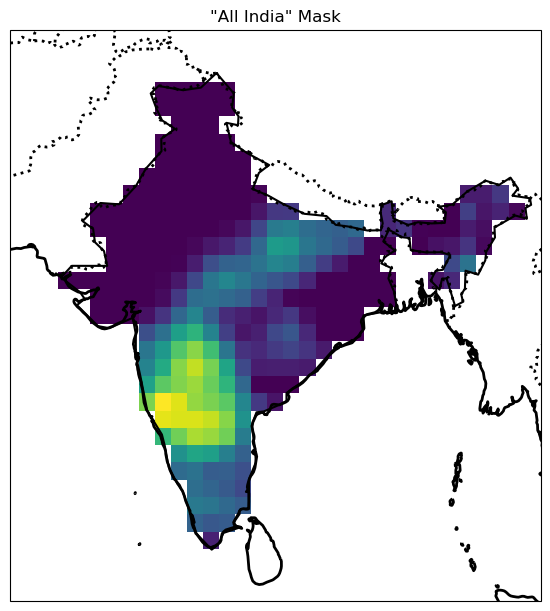

In [83]:
# Step 2: Load the country shapefile and extract a specific country
shapefile_path = '/glade/work/rneale/shapefiles/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp'
world = gpd.read_file(shapefile_path)

# Select a specific country
country = world[world['NAME'] == 'India']


# Step 3: Reproject country shape to match data (if needed)
if hasattr(da, 'rio'):
    # Use rioxarray if spatial metadata is present
    country = country.to_crs(da.rio.crs)
else:
    country = country.to_crs("EPSG:4326")  # fallback, assuming lat/lon

### Reverse the lat array if needed

# Need to reverse lat sometimes if N->

if da.lat[1]-da.lat[0] < 0:
    da = da.reindex(lat=list(reversed(da.lat)))

#display(da)
# Step 4: Create mask using rasterio
# Create transform
lon = da['lon'].values
lat = da['lat'].values



res_lon = (lon[1] - lon[0])
res_lat = (lat[1] - lat[0])

transform = Affine.translation(lon[0] - res_lon / 2, lat[0] - res_lat / 2) * Affine.scale(res_lon, res_lat)

# Step 5: Prepare output shape (lat, lon shape)
ny, nx = len(lat), len(lon)


# rasterio expects shapes in GeoJSON-like format
mask = geometry_mask([geom.__geo_interface__ for geom in country.geometry],
                     out_shape=(ny, nx),
                     transform=transform,
                     invert=True)  # True to mask *inside* the shape

# Step 5: Apply the mask to the DataArray
# Flip the mask if lat is descending
if lat[0] > lat[-1]:
    mask = mask[::-1]



# Plot with Cartopy
#fig = plt.figure(figsize=(10, 8))
#ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the raster (assumes lat/lon coords)
#data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', cbar_kwargs={'label': 'Value'})

# Add country borders and coastlines
#ax.add_feature(cfeature.BORDERS, linewidth=0.5)
#ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
#ax.set_title("Raster Data over India")
#ax.set_extent([65, 100, 5, 40], crs=ccrs.PlateCarree())  # Approximate bounding box for India

#plt.show()














# Now mask the values

masked_da = da.where(mask)


lon2d, lat2d = np.meshgrid(lon, lat)


# If data is lat/lon
data_crs = ccrs.PlateCarree()


fig, axs = plt.subplots(figsize=(6, 6),subplot_kw={'projection': ccrs.PlateCarree()},constrained_layout=True)


# Original data
#p0 = axs[0].pcolormesh(lon2d, lat2d, da.values, shading='auto', cmap='viridis')
#axs[0].set_title("Original Raster")
#axs[0].set_xlabel("Longitude")
#axs[0].set_ylabel("Latitude")
#axs[0].add_feature(cf.COASTLINE)
#fig.colorbar(p0, ax=axs[0], orientation='horizontal', label=da.name)




# Masked data (India masked out)
p1 = axs.pcolormesh(lon2d, lat2d, masked_da.values, shading='auto', cmap='viridis')
axs.set_title('"All India" Mask')
axs.set_xlabel("Longitude")
axs.set_ylabel("Latitude")
axs.set_ylim([5,38])
axs.set_xlim([65,98])
axs.add_feature(cfeature.COASTLINE,lw=2)
axs.add_feature(cfeature.BORDERS, linestyle=':',lw=2)



india = world[world['NAME'] == 'India']
india.boundary.plot(ax=axs, edgecolor='black')


